# Kua Lik Kang SUKD2201215

# Import all Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and Read Dataset

In [11]:
# Load transactions datasetdf
df= pd.read_csv("fruit_transactions.csv")

# Display first few rows


In [12]:
!pip install mlxtend


Defaulting to user installation because normal site-packages is not writeable


# Convert transactions into a list of lists and binary matrix format

In [14]:
from mlxtend.preprocessing import TransactionEncoder

# Convert transactions into a list of lists
transactions = df["Items"].apply(lambda x: x.split(",")).tolist()  # Fix function call and variable name

# Convert transactions into binary matrix format
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)  # Use correct variable name

# Convert to DataFrame
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)  # Fix column reference

# Display processed data
print(df_encoded.head())


    Apple   Banana   Blueberry   Grape   Kiwi   Mango   Orange   Pear  \
0    True    False        True   False  False    True    False  False   
1   False     True       False   False  False   False    False  False   
2   False    False       False   False  False   False    False  False   
3   False    False       False   False  False   False    False  False   
4   False    False        True    True  False   False    False   True   

    Pineapple   Strawberry  ...  apple  banana  blueberry  grape   kiwi  \
0       False        False  ...  False   False      False  False  False   
1       False        False  ...  False   False      False  False  False   
2       False        False  ...  False   False      False  False  False   
3       False        False  ...  False   False      False  False   True   
4        True        False  ...  False   False      False  False  False   

   mango  orange   pear  pineapple  strawberry  
0  False   False  False      False       False  
1  False   F

# Apply Apriori Algorithm

In [18]:
# Add mlxtend library for frequent pattern 
from mlxtend.frequent_patterns import apriori

# Apply Apriori algorithm with minimum support of 0.05
frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True)

# Display frequent itemsets
frequent_itemsets.head()

,support,itemsets
0,0.340,(Apple)
1,0.298,(Banana)
2,0.298,(Blueberry)
3,0.306,(Grape)
4,0.290,(Kiwi)


# Generate Association Rules

In [19]:
from mlxtend.frequent_patterns import association_rules

# Generate rules with a minimum confidence threshold of 0.5 (50%)
rules = association_rules(frequent_itemsets, metric="comfidence", min_threshold=0.5)

# Display association rules
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()

,antecedents,consequents,support,confidence,lift
0,"(blueberry, Kiwi)",(Apple),0.056,0.500000,1.470588
1,"(Apple, Kiwi)",(blueberry),0.056,0.509091,1.674641
2,"(Mango, Apple)",(Pear),0.050,0.500000,1.612903
3,"(Mango, Apple)",(strawberry),0.058,0.580000,1.768293
4,"(Orange, mango)",(Apple),0.050,0.500000,1.470588


# Visualize & Interpret Result

In [1]:
# Sort rules by lift and get top 10
top_rules = rules.sort_values(by='lift', ascending=False). head(10)

# Plot bar chart for top 10 rules based on lift
plt.figure(figsize=(10,5))
plt.barh(range(len(top_rules)), top_rules['lift'], color='green')
plt.yticks(range(len(top_rules)), [f"{list(a)} -> {list(c)}" for a,c in zip(top_rules['antecedents'], top_rules['consequents'])])
plt.title("Top 10 Association Rules by Lift")
plt.xlabel("Lift Values")
plt.gca().invert_yaxis()
plt.show()

SyntaxError: positional argument follows keyword argument (3617272801.py, line 2)

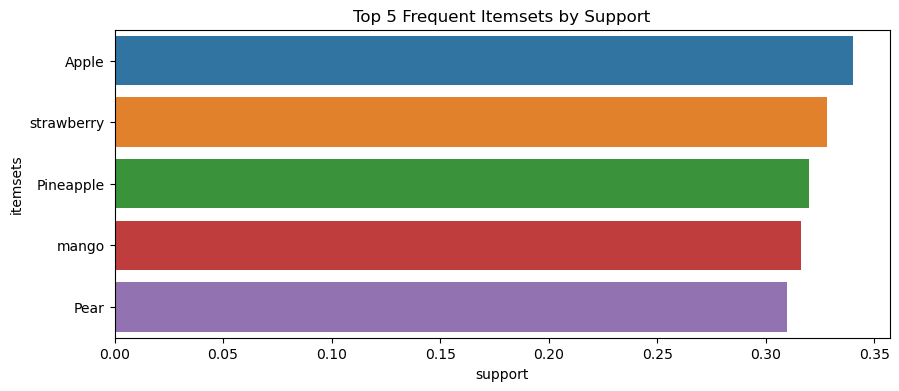

In [28]:
# Sort frequent itemsets by support
top_rules = rules.sort_values(by='support', ascending-False). head(10)

# Convert to strings
top_frequent['frequent_itemsets'] = top_frequent["itemsets"].apply (lambda x: ', '.join(list(x)))

# Plot the sorted bar chart
plt.figure(figsize=(10,5))
plt.barplot(x='support', y='itemsets', data=top_frequent)
plt.title("Top 5 frequent itemsets by support")
plt.show()

# Finding and Conclusion

After applying the Apriori Algorithm to analyze fruit purchases, we discovered strong associations between commonly bought items. The Top 10 associations by Lift revealed which fruit combinations are frequently purchased together and how strongly they are related.

Interpretation Result
- High Lift Values Indicate Strong Relationships
    - A higher Lift value means buying the first item significantly increases the chance of buying the second.

- Example:
    - {Grape, Kiwi} â†’ {Pineapple}
    - Lift â‰ˆ 1.9 â†’ If a customer buys Grape & Kiwi, they are 1.9 times more likely to also buy Pineapple.
    - Business Opportunity â†’ Bundle these fruits together in promotions.

- Another example:
    - {Banana, Grape} â†’ {Blueberry}
    - Lift â‰ˆ 1.8 â†’ Strong connection between these fruits.

Recommendation
1. Optimize Product Placement
    - Place Kiwi near Pineapple to boost cross-sales.
    - Banana & Blueberry should be grouped together in the store layout.
    
2. Create Promotion
    - Offer discounts on "Apple + Banana" combos since they are frequently bought together.
    - Introduce seasonal offers like "Buy 2 Grapes, Get 1 Strawberry Free".

3. Improve inventory planning
    - Ensure consistent stock levels for high-lift items to avoid missed sales.
    - If an item like "Blueberry" is running low, increase supply when Banana sales rise.

# Exercise 

Case Study: Optimizing Book Bundles for a Local Bookstore Using Market Basket Analysis

A local bookstore, Readersâ€™ Haven, wants to analyze customer purchase patterns to identify books frequently bought together. The goal is to create targeted book bundles, improve shelf placements, and design personalized recommendations for their online store. The bookstore has provided a dataset of 500 transactions from the past year.

Objective:
1. Identify frequent book combinations using association rule mining.
2. Compute key metrics (support, confidence, lift) to validate associations.
3. Propose data-driven strategies for promotions and inventory management.

Dataset Description
File: book_transactions.csv
Columns:
1. TransactionID: Unique identifier for each purchase (e.g., T001, T002).
2. Items: Comma-separated list of book titles (e.g., â€œThe Alchemist, Atomic Habitsâ€).

Tasks for Students
1. Preprocess Data:
 - Clean and standardize book titles (e.g., lowercase).
 - Convert transaction data into a binary matrix (1 = purchased, 0 = not purchased).
2. Frequent Itemset Identification:
 - Use the Apriori algorithm to find itemsets with a minimum support of 5%.
3. Association Rule Mining:
- Compute rules with a minimum confidence of 40% and filter rules with lift > 1.
4. Visualization:
- Create visualizations to highlight top frequent itemsets and high-lift rules.
5. Recommendations:
- Suggest 2â€“3 actionable strategies for bundling, promotions, or shelf placement.

Self-reflective Exercise
1. How does adjusting min_support impact the number of rules generated?
2. Why is a lift value >1 important for actionable recommendations?
3. How would you handle typos or alternate book titles (e.g., â€œPower of Habitâ€ vs. â€œThe Power of Habitâ€)?

Deliverables
Code: A Python script implementing preprocessing, analysis, and visualization.
Report:
1. Top 3 frequent book combinations.
2. The strongest rule (highest lift) and its business implication.
3. Two promotional strategies (e.g., bundle deals or discounts).
